# Text-to-Image Search System

This notebook builds a simple semantic image search pipeline with OpenAI CLIP through Hugging Face Transformers. It converts every image in the `Images` folder into an embedding, converts a user text query into the same embedding space, and returns the image whose visual meaning is closest to the query.


## 1. Import Required Libraries

The notebook uses `transformers` for CLIP, `PIL` for image loading, `torch` for tensor operations, and `os` for reading the image directory.


In [1]:
from transformers import CLIPModel , CLIPProcessor
from PIL import Image 
import torch 
import os 

/home/lakshay/Multimodal_Embeddings/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the CLIP Model and Processor

`openai/clip-vit-base-patch32` provides a shared representation space for text and images. The processor prepares raw images and text prompts so they match the model's expected input format.


In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 63410.05it/s]


## 3. Create Image Embeddings

Each image is loaded from the `Images` directory, encoded with CLIP's vision model, projected into the CLIP embedding space, and L2-normalized. Normalization makes cosine-style similarity possible with a simple dot product.


In [17]:
image_embedding = []
image_dir = "/home/lakshay/Multimodal_Embeddings/Text_Image_Search_System/Images"
image_files = os.listdir(image_dir)
image_paths = []

for filename in image_files:
    path = os.path.join(image_dir, filename)
    image = Image.open(path)

    inputs = processor(images=image,
                       return_tensors="pt",
                       padding=True)

    with torch.no_grad():
        outputs = model.vision_model(**inputs)
        features = model.visual_projection(outputs.pooler_output)

    features = features / features.norm(p=2, dim=-1, keepdim=True)

    image_embedding.append(features)
    image_paths.append(path)

## 4. Build the Search Index

The individual image embeddings are stacked into one tensor. Each row represents one image, and `image_paths` keeps the matching file path for every row.


In [21]:
image_embedding = torch.cat(image_embedding, dim=0)

## 5. Validate the Embedding Matrix

The printed shape confirms how many images were indexed and the embedding dimensionality produced by this CLIP pipeline.


In [9]:
print(image_embedding.shape)

torch.Size([10, 768])


## 6. Define Text Search

The `search` function embeds a text query, normalizes the text embedding, compares it against every image embedding, and returns the path of the highest-scoring image.


In [18]:
def search(query):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model.text_model(**inputs)
        text_features = model.text_projection(outputs.pooler_output)

    text_features = (
        text_features
        / text_features.norm(
            dim=-1,
            keepdim=True
        )
    )

    scores = torch.matmul(
        text_features,
        image_embedding.T
    )

    best_index = scores.argmax().item()

    return image_paths[best_index]

## 7. Run a Single Best-Match Query

This example searches for the most relevant image for the query `Horse` and prints the selected image path.


In [23]:
result = search(
    "Horse"
)

print(result)

/home/lakshay/Multimodal_Embeddings/Text_Image_Search_System/Images/horse.jpg


## 8. Compute Top-K Results

Instead of returning only the best match, this cell calculates the top three image matches. This is useful when multiple images may be semantically related to the query.


In [26]:
query = "Horse"

inputs = processor(
    text=[query],
    return_tensors="pt",
    padding=True,
    truncation=True
)

with torch.no_grad():
    outputs = model.text_model(**inputs)
    text_features = model.text_projection(outputs.pooler_output)

text_features = text_features / text_features.norm(dim=-1, keepdim=True)
scores = torch.matmul(text_features, image_embedding.T)

top_k = 3
values, indices = torch.topk(scores, k=top_k)

## 9. Display the Top Matches

The highest-scoring images are opened and displayed in ranked order, making it easy to visually inspect whether the CLIP retrieval result matches the query intent.


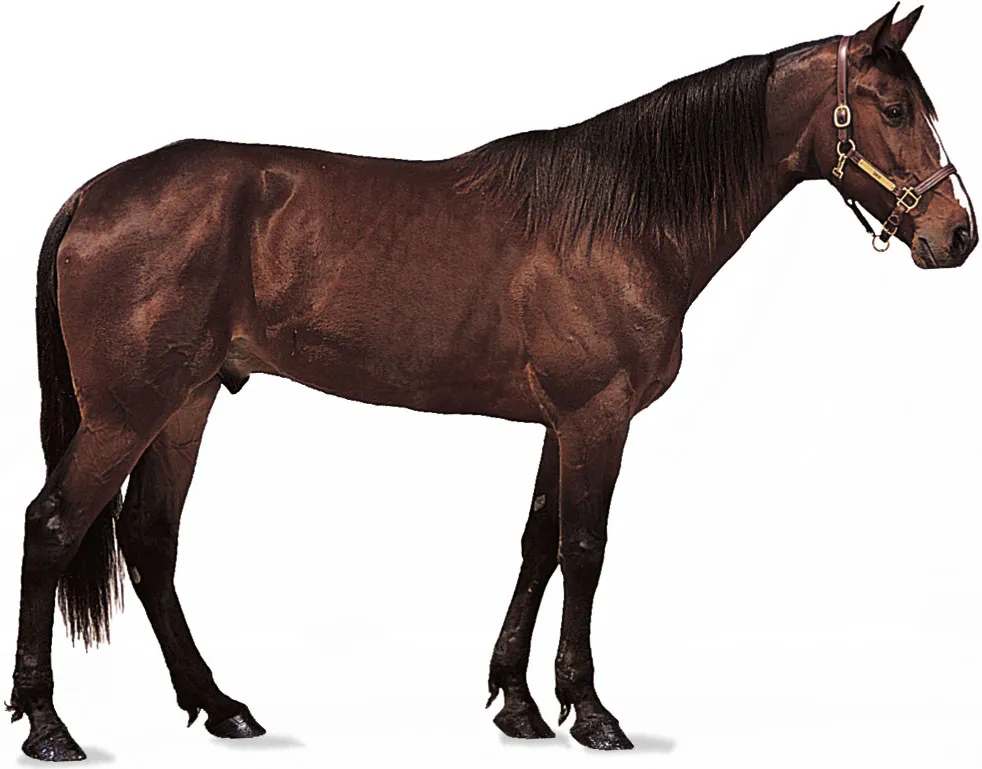

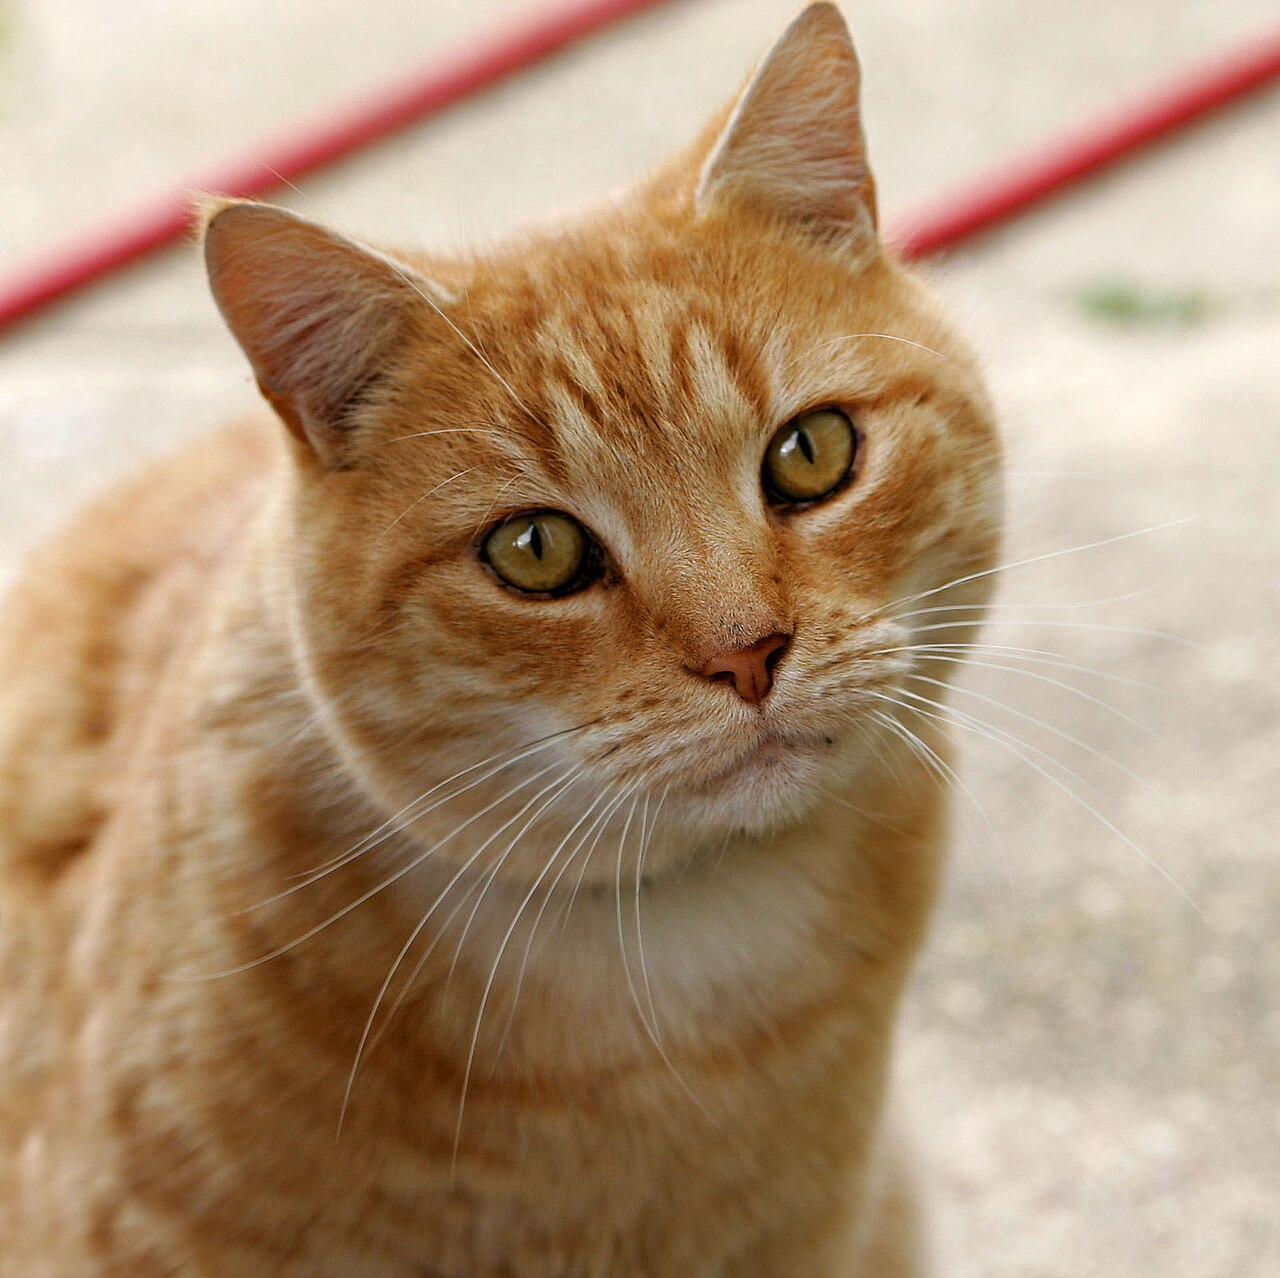

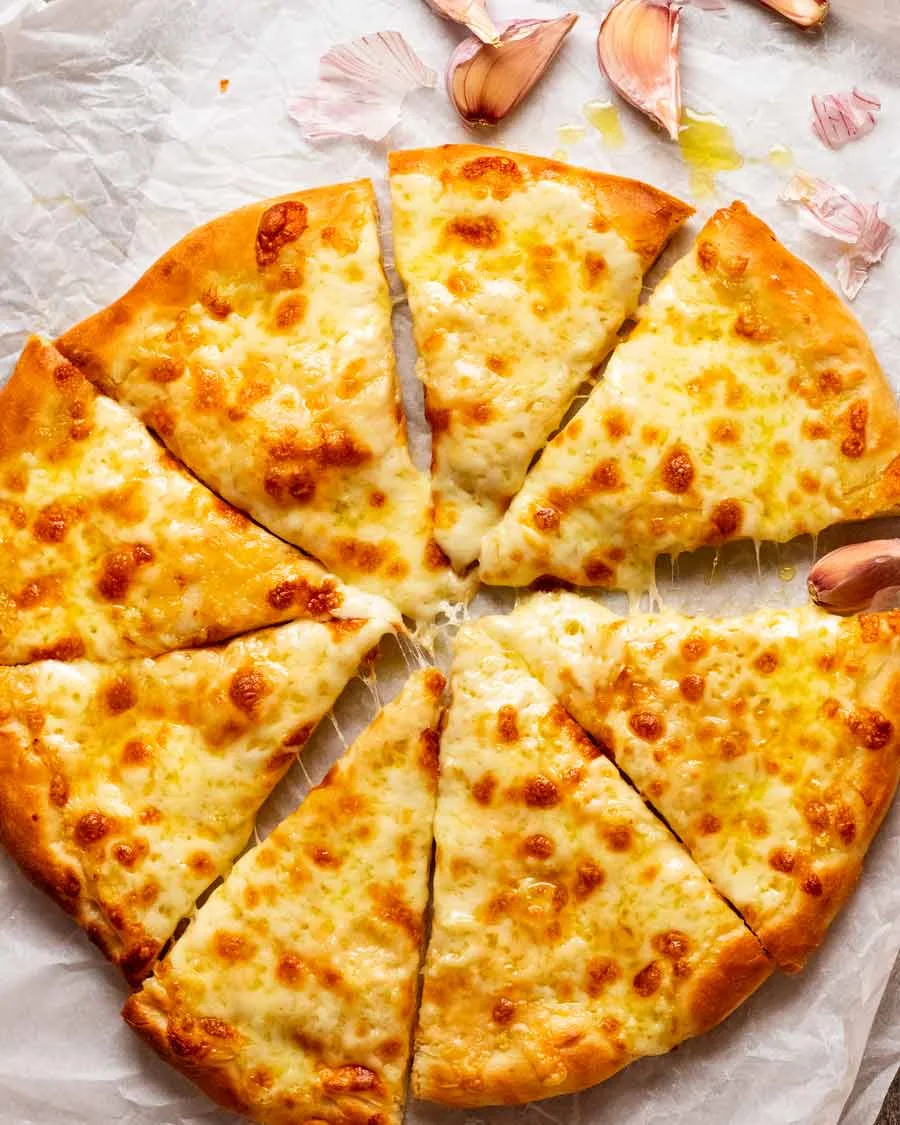

In [27]:
from IPython.display import display

for idx in indices[0]:
    display(Image.open(image_paths[idx]))